Contributors: Thomas Asikis, Lucas Bottcher
## Imports

In [328]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
import torch
from neural_control.controllers import FullyConnectedRegressionController, imitatation_learn
from neural_control.dynamics import DualSourcingModel
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from plotly import graph_objects as go
from dual_sourcing.utilities import sample_trajectories_dual_index

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Sourcing Problem Parameters

In [329]:
sourcing_parameters = dict(ce=20,
                           cr=0,
                           le=0,
                           lr=2,
                           h=5,
                           b=495,
                           T=50)

## Dual-Index Policy Sample Generation
Here we use the dual index policy to generate a number of samples that will be used for imitiation learning.

In [330]:
state_trajectories, qr_trajectories, qe_trajectories =\
    sample_trajectories_dual_index(n_trajectories=128, optimization_samples=200, **sourcing_parameters)

costs (mean/std): [49.8831   41.637775 34.572    29.084975 25.223325 23.30465  23.686525] [0.697861334514999, 0.6116547490498014, 0.48782488208156166, 0.4191510016520653, 0.35496807043754053, 0.40296093492468593, 0.5345206835856817]
Delta*: 5
z_e*: 4


RuntimeError: The expanded size of the tensor (50) must match the existing size (51) at non-singleton dimension 0.  Target sizes: [50].  Tensor sizes: [51]

## NNC Initialization
Here we initialize an NNC model and set  its hyperparameters for training.

In [273]:
### One can experiment with different layer architectures and activations per layer
nnc_hyperparameters = dict(
    n_hidden_units = [64,32,16,8,4]
)

### We use celu non-linearities for the input layer, hidden layers, and output layer
nnc_hyperparameters['n_activations'] = [torch.nn.functional.celu]*(2 + len(nnc_hyperparameters['n_hidden_units']))


fcc = FullyConnectedRegressionController(lr=sourcing_parameters['lr'], 
                                         le=sourcing_parameters['le'], 
                                         n_hidden_units= nnc_hyperparameters ['n_hidden_units'],
                                         activations=nnc_hyperparameters['n_activations']
                                        ) # controller neural network object


The imitation learning optimizer and the learning process are called:

In [274]:
optimizer = torch.optim.Adam(list(fcc.parameters()), lr=0.001)
losses = imitatation_learn(
                      fcc,
                      lr=sourcing_parameters['lr'],
                      le=sourcing_parameters['le'],
                      optimizer=optimizer,
                      state_trajectories=state_trajectories,
                      qr_trajectories=qr_trajectories,
                      qe_trajectories=qe_trajectories,
                      minibatch_size=64,
                      epochs=3000
)

The goal of the optimizer is to minimize the mean squared error (MSE) between $q^{\rm e}_t, q^{\rm r}_t$ values of dual index and NNC.
NNC tries to learn those values by receiving the following inputs:
- previous inventory: $I_t$ 
- previous expendited order positions: $(q^{\rm e}_{t-1},\dots, q^{\rm e}_{t-l_{\rm e}})$
- previous regular order positions: $(q^{\rm r}_{t-1},\dots, q^{\rm r}_{t-l_{\rm r}})$

Next we plot the MSE over learning epochs:

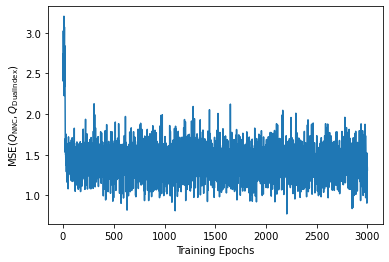

In [275]:
plt.plot(losses)
plt.xlabel(r'Training Epochs')
plt.ylabel(r'$\mathrm{MSE}(Q_\mathrm{NNC},Q_{\mathrm{Dual Index}})$')
plt.show()

For certain initializations, we observe that the learning loss decreases significantly in the first 400-500 epochs and then stabilizes around 1.2-1.5. Since the loss does not converge to 0, we conclude that the proposed architecture and inputs are not capable to fully overfit on the dual sourcing behavior.

## Dynamics Initialization
To further optimize NNC (''fine tuning''), we now apply gradient propagation to the inventory evolution equation:

$I_t = I_{t-1} + q^{\rm e}_{t-l_{\rm e}} + q^{\rm r}_{t-l_{\rm r}} - D_t$

where $I_0, q^{\rm e}_{t},q^{\rm r}_{t}$ are NNC outputs.

In [276]:
dsd = DualSourcingModel(fcc, I_0=4, **sourcing_parameters) # Dual Sourcing Dynamics object

We preserve the best performing model in training, assuming that the neural network generalizes well during training and that our training sample is large enough.

In [277]:
best_loss = [np.infty]
best_model = [None]

We observe that we have a neural network that outputs $q^{\rm r}_{t-l_{\rm r}}, q^{\rm e}_{t-l_{\rm e}}$ given the input described above.
The initial inventory $I_0$ is independent of inputs and can be learned separately (in a way that is similar to learning a bias term of a neural network).
We use separate optimizers to learn order quantities and initial inventory.
This may create learning variance, as one optimizer may overfit on a value that is directly changed by another optimizer. 
To reduce the learning variance, we let the order optimizer operate on 7 out of 10 learning epochs and the inventory optimizer on the remaining epochs.

In [288]:
optimizer = torch.optim.RMSprop(#[dsd.I_0],
                                list(fcc.parameters()), 
                                lr=5*1e-4
                               )
optimizer2 = torch.optim.RMSprop([dsd.I_0],
                                #list(fcc.parameters()), 
                                lr=1e-2
                               )

We now fine tune the model after imitation, in order to generalize and hopefully outperform the method used to train the model.
To do so, we repetively train and fine tune the parameters of 128 trajectories generated by setting a specific random seed. We do not resample new trajectories, as we want the network to overfit on the process. Sampling new samples could increase the input variance, and could potentially slow/prohibit convergence.

In [289]:
fine_tuning_iterations = 1000
minibatch_size = 128
random_seed = 4
all_training_costs = []
for it in range(fine_tuning_iterations):
    optimizer.zero_grad()
    optimizer2.zero_grad()
    def closure():
        dsd.reset(minibatch_size, seed=random_seed+1)
        total_costs = 0
        for i in range(dsd.T):
            current_costs, demands, current_inventories, qr, qra, qe, qea = dsd.simulate()
            total_costs = current_costs.mean() + total_costs
        total_costs.backward()
        if it % 20 == 0:
            print(total_costs/dsd.T)
        if total_costs < best_loss[0]:
            best_loss[0] = total_costs.detach().cpu().item()
            best_model[0] = deepcopy(fcc.state_dict())
            all_training_costs.append(total_costs/dsd.T)
        return total_costs
    if it % 10 > 6:
        optimizer2.step(closure)
    else:
        optimizer.step(closure)

tensor(30.1187, grad_fn=<DivBackward0>)
tensor(26.4469, grad_fn=<DivBackward0>)
tensor(27.4586, grad_fn=<DivBackward0>)
tensor(26.7953, grad_fn=<DivBackward0>)
tensor(31.4695, grad_fn=<DivBackward0>)
tensor(33.1633, grad_fn=<DivBackward0>)
tensor(31.1664, grad_fn=<DivBackward0>)
tensor(24.5383, grad_fn=<DivBackward0>)
tensor(36.3570, grad_fn=<DivBackward0>)
tensor(32.2398, grad_fn=<DivBackward0>)
tensor(23.9789, grad_fn=<DivBackward0>)
tensor(35.3992, grad_fn=<DivBackward0>)
tensor(23.9875, grad_fn=<DivBackward0>)
tensor(34.3156, grad_fn=<DivBackward0>)
tensor(23.4141, grad_fn=<DivBackward0>)
tensor(36.1250, grad_fn=<DivBackward0>)
tensor(32.6328, grad_fn=<DivBackward0>)
tensor(23.4141, grad_fn=<DivBackward0>)
tensor(32.9461, grad_fn=<DivBackward0>)
tensor(26.6609, grad_fn=<DivBackward0>)
tensor(23.3117, grad_fn=<DivBackward0>)
tensor(23.3695, grad_fn=<DivBackward0>)
tensor(26.5133, grad_fn=<DivBackward0>)
tensor(23.3078, grad_fn=<DivBackward0>)
tensor(23.2625, grad_fn=<DivBackward0>)


In [290]:
fig = px.line(torch.log10(torch.stack(all_training_costs).detach()).numpy())
fig.data[0].showlegend = False
fig.layout.xaxis.title = 'Training Epochs'
fig.layout.yaxis.title = r'$log_{10}(\bar{c})$'
fig

The above learning curve can be used to monitor learning.

After successful fine tuning we load the best performing model during training.

In [291]:
#best_model_load = torch.load('nnc_best_model_2.pt', map_location='cpu')
#print(best_model_load)
#fcc.load_state_dict(best_model_load)
fcc.load_state_dict(best_model[0])

<All keys matched successfully>

We often train for $T=50$, but to study the ability of the model to generalize we report the average costs per timestep for $2048$ new samples and $T' = 1000$

In [295]:
fine_tuning_iterations = 1

for it in range(fine_tuning_iterations):

    dsd.reset(256)
    total_costs = 0
    for i in range(dsd.T+20000):
        current_costs, demands, current_inventories, qr, qra, qe, qea = dsd.simulate()
        total_costs = current_costs.mean() + total_costs
    if it % 10 == 0:
        print('Reported mean cost per timestep is: ' + str(total_costs.item()/(dsd.T+20000)))

Reported mean cost per timestep is: 23.2031966957606


In [318]:
torch.save(best_model[0], 'nnc_best_model_dual_index_imitation.pt')

## Comparison 
First, we generate $100$ new dual-index samples.
These will be used to compare performance on unseen samples for NNC.

In [317]:
sourcing_parameters = dict(ce=20,
                           cr=0,
                           le=0,
                           lr=2,
                           h=5,
                           b=495,
                           T=1000)

state_trajectories, qr_trajectories, qe_trajectories =\
    sample_trajectories_dual_index(n_trajectories=1000, optimization_samples=100, seed=25, **sourcing_parameters)

costs (mean/std): [49.8032  41.76105 34.675   29.06605 25.1852  23.3738  23.74275] [0.6913438531095245, 0.5807885161614771, 0.5478202905215092, 0.39234743866407806, 0.3617270023683941, 0.40837082079003556, 0.489926491600237]
Delta*: 5
z_e*: 4


In [297]:
dsd.reset(1)
def evaluate_nnc_on_sample(state_trajectories, 
                           sample_id):
    
    fixed_demands = state_trajectories[sample_id, 1:, 1].unsqueeze(-1)

    nn_inv = dsd.learned_I_0.detach().clone()
    dsd.reset(1)
    nn_qr = [torch.zeros([1,1])]*(dsd.lr+1)
    nn_qe = [torch.zeros([1,1])]*(dsd.le+1)
    nn_ci = []
    all_nn_inv = [nn_inv.item()]
    D = torch.tensor(0.0).unsqueeze(0).unsqueeze(0)
    for i in range(sourcing_parameters["T"]):
        qr, qe = fcc(D, nn_inv, nn_qr, nn_qe)
        D = fixed_demands[i].unsqueeze(0)
        nn_qr.append(qr)
        nn_qe.append(qe)
        qra = nn_qr[-dsd.lr-1]
        qea = nn_qe[-dsd.le-1]
        c_i, nn_inv = dsd.replay_step(nn_inv, D, qra, qea, qr, qe)
        nn_ci.append(c_i)
        all_nn_inv.append(nn_inv.item())
    return all_nn_inv, nn_qr, nn_qe, nn_ci, torch.stack(nn_ci).mean()

In [298]:
def evaluate_di_on_sample(state_trajectories, 
                          qr_trajectories, 
                          qe_trajectories, 
                          sample_id):
    
    dsd.reset(1)
    fixed_demands = state_trajectories[sample_id, 1:, 1].unsqueeze(-1)

    ds_inv = state_trajectories[sample_id, 0, 0].unsqueeze(0).unsqueeze(0)
    dsd.reset(1)
    all_qr = [0]*dsd.lr
    all_qe = [0]*dsd.le
    all_ci = []
    all_inv = [ds_inv.detach().item()]
    for i in range(sourcing_parameters["T"]):
        D = fixed_demands[i].unsqueeze(0)
        if dsd.le == 0:
            qe = qe_trajectories[sample_id, i+1]
        else:
            qe = qe_trajectories[sample_id, dsd.le+i]
    
        if dsd.lr == 0:
            qr = qr_trajectories[sample_id, i+1]
        else:
            qr = qr_trajectories[sample_id, dsd.lr+i]
            
        all_qr.append(qr)
        all_qe.append(qe)
        qra = all_qr[-dsd.lr-1]
        qea = all_qe[-dsd.le-1]
        c_i, ds_inv = dsd.replay_step(ds_inv, D, qra, qea, qr, qe)
        all_inv.append(ds_inv.detach().item())
        all_ci.append(c_i)
    # test if calculated inventories and costs are the same as the ones reported
    # from the dual sourcing code
    assert torch.all(torch.tensor(all_inv) == state_trajectories[sample_id, :, 0])
    assert torch.all(torch.tensor(all_ci) == state_trajectories[sample_id, 1:, -1])
    return all_inv, all_qr, all_qe, all_ci, torch.stack(all_ci).mean()

In [299]:
cost_ratios = []
cost_nn = []
cost_di = []

samples = 400
for i in range(samples):
    print("%d/%d samples completed"%(i,samples))
    nn_inv, nn_qr, nn_qe, nn_ci, nn_mean_cost = evaluate_nnc_on_sample(state_trajectories, 
                                                                       i)
    
    di_inv, di_qr, di_qe, di_ci, di_mean_cost = evaluate_di_on_sample(state_trajectories, 
                                                                      qr_trajectories, 
                                                                      qe_trajectories, 
                                                                      i)
    cost_nn.append(nn_mean_cost.detach().item())
    cost_di.append(di_mean_cost.detach().item())
    cost_ratios.append(nn_mean_cost.detach().item()/di_mean_cost.detach().item())

0/400 samples completed
1/400 samples completed
2/400 samples completed
3/400 samples completed
4/400 samples completed
5/400 samples completed
6/400 samples completed
7/400 samples completed
8/400 samples completed
9/400 samples completed
10/400 samples completed
11/400 samples completed
12/400 samples completed
13/400 samples completed
14/400 samples completed
15/400 samples completed
16/400 samples completed
17/400 samples completed
18/400 samples completed
19/400 samples completed
20/400 samples completed
21/400 samples completed
22/400 samples completed
23/400 samples completed
24/400 samples completed
25/400 samples completed
26/400 samples completed
27/400 samples completed
28/400 samples completed
29/400 samples completed
30/400 samples completed
31/400 samples completed
32/400 samples completed
33/400 samples completed
34/400 samples completed
35/400 samples completed
36/400 samples completed
37/400 samples completed
38/400 samples completed
39/400 samples completed
40/400 sam

320/400 samples completed
321/400 samples completed
322/400 samples completed
323/400 samples completed
324/400 samples completed
325/400 samples completed
326/400 samples completed
327/400 samples completed
328/400 samples completed
329/400 samples completed
330/400 samples completed
331/400 samples completed
332/400 samples completed
333/400 samples completed
334/400 samples completed
335/400 samples completed
336/400 samples completed
337/400 samples completed
338/400 samples completed
339/400 samples completed
340/400 samples completed
341/400 samples completed
342/400 samples completed
343/400 samples completed
344/400 samples completed
345/400 samples completed
346/400 samples completed
347/400 samples completed
348/400 samples completed
349/400 samples completed
350/400 samples completed
351/400 samples completed
352/400 samples completed
353/400 samples completed
354/400 samples completed
355/400 samples completed
356/400 samples completed
357/400 samples completed
358/400 samp

In [331]:
(np.array(cost_ratios) < 1).sum()/len(cost_ratios)

0.83

In [301]:
np.mean(cost_ratios)

0.9928225712152675

Below we plot the distribution of the mean cost per step ratio between NNC and DI.

In [302]:
fig = go.Figure(go.Histogram(x=cost_ratios))
fig.add_vline(x=np.mean(cost_ratios))
fig.layout.xaxis.title = r'$\dfrac{\bar{c}_{\text{NNC}}}{\bar{c}_{\text{Dual Index}}}$'
fig.layout.yaxis.title = 'Count'
fig

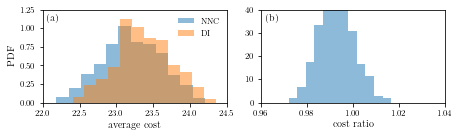

In [303]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns

# customized settings
params = {  # 'backend': 'ps',
    'font.family': 'serif',
    'font.serif': 'Latin Modern Roman',
    'font.size': 10,
    'axes.labelsize': 'medium',
    'axes.titlesize': 'medium',
    'legend.fontsize': 'medium',
    'xtick.labelsize': 'small',
    'ytick.labelsize': 'small',
    'savefig.dpi': 150,
    'text.usetex': True}
# tell matplotlib about your params
rcParams.update(params)

# set nice figure sizes
fig_width_pt = 469    # Get this from LaTeX using \showthe\columnwidth
golden_mean = (np.sqrt(5.) - 1.) / 2.  # Aesthetic ratio
ratio = golden_mean
inches_per_pt = 1. / 72.27  # Convert pt to inches
fig_width = fig_width_pt * inches_per_pt  # width in inches
fig_height = fig_width*ratio  # height in inches
fig_size = [fig_width, 0.5*fig_height]
rcParams.update({'figure.figsize': fig_size})


fig, ax = plt.subplots(ncols=2)
ax[0].text(0.02*(24.5-22)+22,0.88*1.25,r"(a)")
ax[0].hist(cost_nn,alpha=0.5,bins=12,density=True,label=r"NNC")
ax[0].hist(cost_di,alpha=0.5,bins=12,density=True,label=r"DI")
ax[0].set_xlim(22,24.5)
ax[0].set_ylim(0,1.25)
ax[0].set_xlabel(r"average cost")
ax[0].set_ylabel(r"PDF")
ax[0].legend(loc=1,fontsize=8,frameon=False)

ax[1].text(0.02*(1.04-0.96)+0.96,0.88*40,r"(b)")
ax[1].hist(cost_ratios,bins=12,alpha=0.5,density=True)
ax[1].set_xlim(0.96,1.04)
ax[1].set_ylim(0,40)
ax[1].set_xlabel(r"cost ratio")

plt.tight_layout()
plt.margins(0,0)
plt.savefig("cost_comparison_dual_index.png", dpi = 300, bbox_inches = 'tight', pad_inches = 0.05)
plt.show()


## Single sample comparison
Now we compare the 2 models on a single random sample from the above to examine the difference between NNC and DI control trajectories.

In [309]:
fixed_demands = state_trajectories[1, 1:, 1].unsqueeze(-1)
nn_inv, nn_qr, nn_qe, nn_ci, nn_mean_cost = evaluate_nnc_on_sample(state_trajectories, 1)
di_inv, di_qr, di_qe, di_ci, di_mean_cost = evaluate_di_on_sample(state_trajectories, qr_trajectories, qe_trajectories, 1)

In [310]:
a = go.Scatter(y=[x.item() for x in nn_qr], name='NNC')
b = go.Scatter(y=di_qr, name='DI')
fig = go.Figure([a,b])
fig.layout.xaxis.title = 'Timestep'
fig.layout.yaxis.title = 'Regular Order'
fig

In [311]:
a = go.Scatter(y=[x.item() for x in nn_qe], name='NNC')
b = go.Scatter(y=di_qe, name='DI')
fig = go.Figure([a,b])
fig.layout.xaxis.title = 'Timestep'
fig.layout.yaxis.title = 'Expedited Order'
fig

In [312]:
a = go.Scatter(y=[x.item() for x in nn_ci], name='NNC')
b = go.Scatter(y=[x.item() for x in di_ci], name='DI')
fig = go.Figure([a,b])
fig.add_hline(nn_mean_cost.detach().item())
fig.add_hline(di_mean_cost.detach().item(),line={'dash':'dash'})
fig.layout.xaxis.title = 'Timestep'
fig.layout.yaxis.title = 'Cost'
fig

In [313]:
a = go.Scatter(y=nn_inv, name='NNC Inventory')
b = go.Scatter(y=di_inv, name='DI Inventory')
c = go.Scatter(y=[x.detach().item() for x in fixed_demands], name='Demand',
               x=torch.arange(1, 1001).tolist() )
fig = go.Figure([a,b, c])
fig.layout.xaxis.title = 'Timestep'
fig.layout.yaxis.title = 'Quantity'
fig


We observe that both methods have similar control outputs.